In [83]:
!pip install ipympl

Defaulting to user installation because normal site-packages is not writeable
    sys-platform (=="darwin") ; extra == 'objc'
                 ~^

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# The Ancestor Game

- Jeu JcJ, tour par tour
- État de départ: une forêt orientée de n noeuds
- Objectif: être le premier à capturer au moins la moitié des noeuds
- Pendant leur tours, les joueurs peuvent faire les actions suivantes:
  - Ajouter un parent
    - Le joueur choisit un noeud sans parent et lui en ajoute un.
    - Aucun cycle ne doit se faire
  - Placer un drapeau
    - Le joueur place un drapeau de sa couleur sur un noeud pas capturé (un noeud peut avoir plusieurs drapeaux, mais un seul de chaque couleur)
  - Capture simple
    - Le joueur capture un noeud avec un drapeau de sa couleur
  - Capture combo
    - Le joueur choisi 2 noeuds avec un drapeau de sa couleur
    - Tous les noeuds pas capturés jusqu'au Least Common Ancestor des 2 noeuds sont capturés par le joueur


Un noeud capturé ne peut pas être recapturé. Capturer un noeud enlève tous les drapeux posés dessus.

## Drapeaux

In [84]:
class Flag:
  def __init__(self, pid):
    self.player_id = pid

## Node en général

In [85]:
class Node:
    def __init__(self, id):
        self.id = id
        self.parent = None

    def set_parent(self, node):
        self.parent = node

    def ancestors(self):
        result = []
        current = self
        while current is not None:
            result.append(current)
            current = current.parent
        return result


## Node du jeu

In [86]:
class GameNode(Node):
    def __init__(self, id):
        super().__init__(id)
        self.flags = []
        self.is_captured = False

    def add_flag(self, flag):
        if not self.is_captured: self.flags.append(flag)

    def get_flags(self):
        return self.flags
    
    def capture(self):
        self.is_captured = True
        self.flags = []

    def has_flag_from_player(self, pid):
        for f in self.flags:
            if f.player_id == pid: return True
        return False

## Player

In [87]:
class Player:

    def __init__(self, pid):
        self.player_id = pid
        self.zones_captured = 0

    def can_capture(self, n1, n2):
        if (n1 == n2 and n1.has_flag_from_player(self.player_id)):
            return True

        if (n1.ancestors()[-1] in n2.ancestors() and n1.has_flag_from_player(self.player_id) and n2.has_flag_from_player(self.player_id)):
            return True
        
        return False

    def capture(self, n1, n2):
        if self.can_capture(n1, n2):
            ancestors_n1 = n1.ancestors()
            ancestors_n2 = n2.ancestors()

            ancestors_n1_set = set(id(node) for node in ancestors_n1)
            lca = next(node for node in ancestors_n2 if id(node) in ancestors_n1_set)

            current = n1
            while current != lca:
                if not current.is_captured:
                    current.capture()
                    self.zones_captured += 1
                current = current.parent

            current = n2
            while current != lca:
                if not current.is_captured:
                    current.capture()
                    self.zones_captured += 1
                current = current.parent

            lca.capture()
            self.zones_captured += 1

    def can_place_flag(self, n):
        return not n.is_captured and not n.has_flag_from_player(self.player_id)

    def place_flag(self, n):
        if (n.has_flag_from_player(self.player_id)): return
        n.add_flag(Flag(self.player_id))

    def can_give_parent(self, n_child, n_parent):
        return n_child.parent is None and not n_child in n_parent.ancestors()

    def give_parent(self, n_child, n_parent):
        n_child.set_parent(n_parent)

In [88]:
import networkx as nx
import matplotlib.pyplot as plt
import random

class AncestorGameDisplayer:
    def __init__(self, n):
        self.n = n
        rng = random.Random(42)

        self.parents = [-1] * n

        self.is_red    = [False] * n
        self.is_blue   = [False] * n

        self.has_blue_F = [False] * n
        self.has_red_F  = [False] * n

    def _get_node_color(self, i):
        if self.is_red[i]:  return "red"
        if self.is_blue[i]: return "blue"
        return "black"

    def _get_f_label(self, i):
        if self.has_blue_F[i] and self.has_red_F[i]: return "both"
        if self.has_blue_F[i]: return "blue"
        if self.has_red_F[i]:  return "red"
        return None

    def show(self):
        G = nx.DiGraph()

        for i in range(self.n):
            G.add_node(i, color=self._get_node_color(i),
                          f_label=self._get_f_label(i))

        for i, p in enumerate(self.parents):
            if p != -1:
                G.add_edge(i, p)

        pos = nx.spring_layout(G, seed=42)
        fig, ax = plt.subplots(figsize=(8, 6))

        nx.draw_networkx_edges(
            G, pos, ax=ax,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=20,
            connectionstyle="arc3,rad=0.2",
            edge_color="gray",
            width=2,
        )
        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_color=["white"] * self.n,
            node_size=800,
            edgecolors=[self._get_node_color(i) for i in range(self.n)],
            linewidths=3,
        )

        for i in range(self.n):
            f = self._get_f_label(i)
            if f is not None:
                x, y = pos[i]
                if f == "both":
                    # Two F labels side by side, offset left and right
                    ax.text(x - 0.02, y, "F", fontsize=11, fontweight="bold",
                            color="red", ha="center", va="center")
                    ax.text(x + 0.02, y, "F", fontsize=11, fontweight="bold",
                            color="blue", ha="center", va="center")
                else:
                    ax.text(x, y, "F", fontsize=12, fontweight="bold",
                            color=f, ha="center", va="center")
                    
        for i in range(self.n):
            x, y = pos[i]
            ax.text(
                x + 0.05, y + 0.05, str(i),
                fontsize=9,
                color="gray",
                ha="left",   # align from left
                va="bottom"  # align from bottom (top-right corner of node)
            )

        ax.set_title("The Ancestor Game", fontsize=14)
        ax.axis("off")
        plt.tight_layout()
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")
        plt.show()
    
    def add_edge(self, child, parent):
        self.parents[child] = parent

    def red_player_capture(self, node):
        self.is_red[node] = True
        self.is_blue[node] = False
        self.has_red_F[node] = False
        self.has_blue_F[node] = False

    def blue_player_capture(self, node):
        self.is_red[node] = False
        self.is_blue[node] = True
        self.has_red_F[node] = False
        self.has_blue_F[node] = False
    
    def red_player_flag(self, node):
        self.has_red_F[node] = True
    
    def blue_player_flag(self, node):
        self.has_blue_F[node] = True


## Game

In [89]:
import random

class Game:
    def __init__(self, p1, p2, node_amount):
        self.players = [p1, p2]
        self.nodes = []
        for i in range(0, node_amount):
            self.nodes.append(GameNode(i))

    def launch(self):
        # ===== CHOOSE RANDOM PLAYER =====
        current_player = random.choice(self.players)
        displayer = AncestorGameDisplayer(len(self.nodes))
        displayer.show()

        # ===== GAMEPLAY LOOP =====
        while True:
            # ===== CHECK WIN CONDITION =====
            for p in self.players:
                if p.zones_captured >= len(self.nodes) / 2:
                    print("Player", p.player_id, "wins!")
                    return

            # ===== PLAYER TURN =====
            print(f"\nPlayer {current_player.player_id}'s turn")
            print("Nodes:", [n.id for n in self.nodes])
            print("Actions: 'p i j' (set parent), 'f i' (flag node), 'c i j' (capture), 'c i i' (capture)")

            action = input("> ").strip().split()

            try:
                if action[0] == "p":
                    i, j = self.nodes[int(action[1])], self.nodes[int(action[2])]
                    if current_player.can_give_parent(i, j):
                        i.set_parent(j)
                        displayer.add_edge(i.id, j.id)
                        
                        print(f"Node {i.id}'s parent is now {j.id}")
                        current_player = self.players[0] if current_player == self.players[1] else self.players[1]
                    else:
                        print(f"Node {i.id} has already a parent or adding this edge makes a cycle")

                elif action[0] == "f":
                    i = self.nodes[int(action[1])]
                    if current_player.can_place_flag(i):
                        i.add_flag(Flag(current_player.player_id))
                        if current_player is self.players[0]:
                            displayer.red_player_flag(i.id)
                        else:
                            displayer.blue_player_flag(i.id)
                            
                        print(f"Flag added to node {i}")
                        current_player = self.players[0] if current_player == self.players[1] else self.players[1]
                    else:
                        print(f"Node {i.id} is captured or already has this player's flag")

                elif action[0] == "c":
                    i, j = self.nodes[int(action[1])], self.nodes[int(action[2])]
                    if current_player.can_capture(i, j):
                        current_player.capture(i, j)
                        if current_player is self.players[0]:
                            displayer.red_player_capture(i.id)
                        else:
                            displayer.blue_player_capture(i.id)
                            
                        print(f"Captured nodes between {i.id} and {j.id}!")
                        current_player = self.players[0] if current_player == self.players[1] else self.players[1]
                    else:
                        print(f"Nodes {i.id} and {j.id} don't have this player's flag or do not share an ancestor")

                else:
                    print("Unknown action, try again.")
                    continue

            except (IndexError, ValueError):
                print("Invalid input, try again.")
                continue

            displayer.show()


# MinMax

In [90]:
from typing import List, Optional
import math

class GameState:
    def getScore(self) -> float:
        raise NotImplementedError

    def getNextState(self, action, player):
        raise NotImplementedError

    def isFinal(self) -> bool:
        raise NotImplementedError

    def getAllActions(self):
        raise NotImplementedError

    def isPlayable(self, action) -> bool:
        raise NotImplementedError

    def getActions(self):
        possibles = []
        if not self.isFinal():
            for action in self.getAllActions():
                if self.isPlayable(action):
                    possibles.append(action)
        return possibles


class AncAct:
    Flag = "Flag"
    Capture = "Capture"
    Parent = "Parent"


class AncestorAction:
    allActions = []

    def __init__(self, player, action, node1, node2=None):
        self.player = player
        self.action = action
        self.node1 = node1
        self.node2 = node2


def generate_all_actions(N):
    actions = []

    for i in range(N):
        actions.append(AncestorAction(1, AncAct.Flag, i))

    for i in range(N):
        for j in range(N):
            if i != j:
                actions.append(AncestorAction(1, AncAct.Parent, i, j))

    for i in range(N):
        for j in range(i, N):
            actions.append(AncestorAction(1, AncAct.Capture, i, j))

    for i in range(N):
        actions.append(AncestorAction(-1, AncAct.Flag, i))

    for i in range(N):
        for j in range(N):
            if i != j:
                actions.append(AncestorAction(-1, AncAct.Parent, i, j))

    for i in range(N):
        for j in range(i, N):
            actions.append(AncestorAction(-1, AncAct.Capture, i, j))

    return actions


class AncestorState(GameState):

    def __init__(self, N):
        self.N = N
        self.whichPlayer = 1

        self.flagged_p1 = [False] * N
        self.flagged_p2 = [False] * N
        self.captured_p1 = [False] * N
        self.captured_p2 = [False] * N

        self.parents: List[Optional[int]] = [None] * N

        if not AncestorAction.allActions:
            AncestorAction.allActions = generate_all_actions(N)

    def copy(self):
        new = AncestorState(self.N)

        new.whichPlayer = self.whichPlayer
        new.flagged_p1 = self.flagged_p1[:]
        new.flagged_p2 = self.flagged_p2[:]
        new.captured_p1 = self.captured_p1[:]
        new.captured_p2 = self.captured_p2[:]
        new.parents = self.parents[:]

        return new

    def getAncestors(self, node):
        current = node
        ancestors = [current]

        while self.parents[current] is not None:
            current = self.parents[current]
            ancestors.append(current)

        return ancestors

    def hasFlag(self, player, node):
        return (player == 1 and self.flagged_p1[node]) or (
            player == -1 and self.flagged_p2[node]
        )

    def isCaptured(self, node):
        return self.captured_p1[node] or self.captured_p2[node]

    def getNbCapturedNodes(self, player):
        arr = self.captured_p1 if player == 1 else self.captured_p2
        return sum(arr)

    def getScore(self):

        CAPTURE_WEIGHT = 1.0
        FLAG_WEIGHT = 0.3
        WIN_SCORE = 1000.0

        p1Captures = self.getNbCapturedNodes(1)
        p2Captures = self.getNbCapturedNodes(-1)

        if p1Captures >= self.N / 2:
            return WIN_SCORE * self.N
        if p2Captures >= self.N / 2:
            return -WIN_SCORE * self.N

        p1Flags = 0
        p2Flags = 0

        for i in range(self.N):
            if not self.isCaptured(i):
                if self.flagged_p1[i]:
                    p1Flags += 1
                if self.flagged_p2[i]:
                    p2Flags += 1

        return CAPTURE_WEIGHT * (p1Captures - p2Captures) + FLAG_WEIGHT * (
            p1Flags - p2Flags
        )

    def getNextState(self, action, player):

        next_state = self.copy()
        next_state.whichPlayer = -player

        if action.action == AncAct.Flag:

            if player == 1:
                next_state.flagged_p1[action.node1] = True
            else:
                next_state.flagged_p2[action.node1] = True

        elif action.action == AncAct.Parent:

            next_state.parents[action.node1] = action.node2

        elif action.action == AncAct.Capture:

            ancestors1 = next_state.getAncestors(action.node1)
            ancestors2 = next_state.getAncestors(action.node2)

            set1 = set(ancestors1)

            lca = next(node for node in ancestors2 if node in set1)

            def capturePath(start):
                current = start

                while current != lca:

                    if not self.isCaptured(current):

                        if player == 1:
                            next_state.captured_p1[current] = True
                        else:
                            next_state.captured_p2[current] = True

                        next_state.flagged_p1[current] = False
                        next_state.flagged_p2[current] = False

                    current = next_state.parents[current]

            capturePath(action.node1)
            capturePath(action.node2)

            if not self.isCaptured(lca):

                if player == 1:
                    next_state.captured_p1[lca] = True
                else:
                    next_state.captured_p2[lca] = True

                next_state.flagged_p1[lca] = False
                next_state.flagged_p2[lca] = False

        return next_state

    def isFinal(self):

        return (
            self.getNbCapturedNodes(1) >= self.N / 2
            or self.getNbCapturedNodes(-1) >= self.N / 2
        )

    def getAllActions(self):

        return AncestorAction.allActions

    def isPlayable(self, action):

        if self.whichPlayer != action.player:
            return False

        if action.action == AncAct.Flag:

            return (
                not self.isCaptured(action.node1)
                and not self.hasFlag(action.player, action.node1)
            )

        if action.action == AncAct.Capture:

            ancestors1 = self.getAncestors(action.node1)
            ancestors2 = self.getAncestors(action.node2)

            return (
                self.hasFlag(action.player, action.node1)
                and self.hasFlag(action.player, action.node2)
                and ancestors1[-1] == ancestors2[-1]
            )

        if action.action == AncAct.Parent:

            ancestors = self.getAncestors(action.node2)

            return (
                self.parents[action.node1] is None
                and action.node1 not in ancestors
            )

        return False

    def toString(self):

        total = ""

        total += "Player 1 flags: "
        total += ", ".join(str(i) for i in range(self.N) if self.flagged_p1[i])
        total += "\n"

        total += "Player 2 flags: "
        total += ", ".join(str(i) for i in range(self.N) if self.flagged_p2[i])
        total += "\n"

        total += "Player 1 captured: "
        total += ", ".join(str(i) for i in range(self.N) if self.captured_p1[i])
        total += "\n"

        total += "Player 2 captured: "
        total += ", ".join(str(i) for i in range(self.N) if self.captured_p2[i])
        total += "\n"

        total += "Parents: "

        for i in range(self.N):
            parent = self.parents[i]
            total += f"{i}->{parent if parent is not None else 'None'}, "

        total += "\n"

        return total


def minMaxDFS(state, maxDepth):

    class StackFrame:

        def __init__(self, state, depth):
            self.state = state
            self.player = state.whichPlayer
            self.depth = depth

            self.actions = state.getActions()
            self.actionIndex = 0

            if self.player == 1:
                self.bestValue = -math.inf
            else:
                self.bestValue = math.inf

            self.bestAction = self.actions[0] if self.actions else None

            if not self.actions:
                self.bestValue = state.getScore()

        def setIfBetterValue(self, idx, score):

            if (
                self.player == 1
                and score > self.bestValue
                or self.player == -1
                and score < self.bestValue
            ):
                self.bestValue = score
                self.bestAction = self.actions[idx]

    stack = [StackFrame(state, 0)]

    rootActions = state.getActions()
    rootBestAction = rootActions[0] if rootActions else None

    while stack:

        frame = stack[-1]

        if frame.actionIndex >= len(frame.actions):

            resultValue = frame.bestValue
            resultAction = frame.bestAction

            stack.pop()

            if stack:

                parent = stack[-1]
                parent.setIfBetterValue(parent.actionIndex - 1, resultValue)

            else:

                rootBestAction = resultAction

        else:

            action = frame.actions[frame.actionIndex]
            nextState = frame.state.getNextState(action, frame.player)

            if nextState.isFinal() or frame.depth >= maxDepth - 1:

                score = nextState.getScore()
                frame.setIfBetterValue(frame.actionIndex, score)
                frame.actionIndex += 1

            else:

                frame.actionIndex += 1
                stack.append(StackFrame(nextState, frame.depth + 1))

    return rootBestAction


def doAncestor(N):

    node = AncestorState(N)

    print(node.toString())

    while not node.isFinal():

        action = minMaxDFS(node, 5)
        node = node.getNextState(action, node.whichPlayer)

        print(node.toString())

# Interface

In [91]:
%matplotlib widget

from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Callable, Dict, Optional

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.text import Text
from matplotlib.widgets import Button

from IPython.display import display, HTML


def draw_displayer_in_axis(displayer: AncestorGameDisplayer, ax: Axes) -> None:
    G = nx.DiGraph()

    for i in range(displayer.n):
        G.add_node(i, color=displayer._get_node_color(i), f_label=displayer._get_f_label(i))

    for i, p in enumerate(displayer.parents):
        if p != -1:
            G.add_edge(i, p)

    ax.clear()

    if G.number_of_edges() == 0:
        pos = nx.circular_layout(G, scale=1.0)
    else:
        pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20,
        connectionstyle="arc3,rad=0.2",
        edge_color="gray",
        width=2,
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=["white"] * displayer.n,
        node_size=800,
        edgecolors=[displayer._get_node_color(i) for i in range(displayer.n)],
        linewidths=3,
    )

    for i in range(displayer.n):
        x, y = pos[i]
        ax.text(
            x + 0.075,
            y - 0.075,
            str(i),
            fontsize=10,
            color="black",
            ha="center",
            va="center",
        )

    for i in range(displayer.n):
        f = displayer._get_f_label(i)
        if f is not None:
            x, y = pos[i]
            if f == "both":
                ax.text(x - 0.02, y, "F", fontsize=11, fontweight="bold", color="red", ha="center", va="center")
                ax.text(x + 0.02, y, "F", fontsize=11, fontweight="bold", color="blue", ha="center", va="center")
            else:
                ax.text(x, y, "F", fontsize=12, fontweight="bold", color=f, ha="center", va="center")

    xs = [coords[0] for coords in pos.values()]
    ys = [coords[1] for coords in pos.values()]
    pad_x = 0.22
    pad_y = 0.28
    ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
    ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)

    ax.set_title("The Ancestor Game", fontsize=14)
    ax.axis("off")
    ax.figure.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.figure.canvas.draw_idle()


class NotebookGameController:
    def __init__(self, game: Game):
        self.game = game
        self.minmax_node = AncestorState(len(game.nodes))
        self.current_player = random.choice(self.game.players)
        self.displayer = AncestorGameDisplayer(len(self.game.nodes))
        self.last_message = f"Player {self.current_player.player_id}'s turn"

    def _sync_display_from_game(self) -> None:
        self.displayer.parents = [-1] * len(self.game.nodes)
        self.displayer.has_red_F = [False] * len(self.game.nodes)
        self.displayer.has_blue_F = [False] * len(self.game.nodes)

        for node in self.game.nodes:
            if node.parent is not None:
                self.displayer.parents[node.id] = node.parent.id

            for flag in node.flags:
                if flag.player_id == self.game.players[0].player_id:
                    self.displayer.has_red_F[node.id] = True
                elif flag.player_id == self.game.players[1].player_id:
                    self.displayer.has_blue_F[node.id] = True

    def _switch_player(self) -> None:
        self.current_player = self.game.players[0] if self.current_player == self.game.players[1] else self.game.players[1]
        self.last_message = f"Player {self.current_player.player_id}'s turn"

    def _winner(self) -> Optional[int]:
        for player in self.game.players:
            if player.zones_captured >= len(self.game.nodes) / 2:
                return player.player_id
        return None

    def render(self, ax: Axes) -> None:
        self._sync_display_from_game()
        draw_displayer_in_axis(self.displayer, ax)
        winner = self._winner()
        if winner is not None:
            ax.set_title(f"The Ancestor Game | Player {winner} wins!", fontsize=14)
        else:
            ax.set_title(f"The Ancestor Game | Player {self.current_player.player_id}", fontsize=14)
        ax.figure.canvas.draw_idle()

    def do_link(self, child_id: int, parent_id: int) -> str:
        try:
            child, parent = self.game.nodes[int(child_id)], self.game.nodes[int(parent_id)]
            if self.current_player.can_give_parent(child, parent):
                child.set_parent(parent)
                message = f"Node {child.id}'s parent is now {parent.id}"
                self._switch_player()
                self.minmax_node = self.minmax_node.getNextState(AncestorAction(self.minmax_node.whichPlayer, AncAct.Parent, child.id, parent.id), self.minmax_node.whichPlayer)
                display(HTML(f"<pre>{self.minmax_node.toString()}</pre>"))
                return message
            return f"Node {child.id} has already a parent or adding this edge makes a cycle"
        except (IndexError, ValueError):
            return "Invalid input, try again."

    def do_flag(self, node_id: int) -> str:
        try:
            node = self.game.nodes[int(node_id)]
            if self.current_player.can_place_flag(node):
                node.add_flag(Flag(self.current_player.player_id))
                message = f"Flag added to node {node.id}"
                self._switch_player()
                self.minmax_node = self.minmax_node.getNextState(AncestorAction(self.minmax_node.whichPlayer, AncAct.Flag, node.id), self.minmax_node.whichPlayer)
                display(HTML(f"<pre>{self.minmax_node.toString()}</pre>"))
                return message
            return f"Node {node.id} is captured or already has this player's flag"
        except (IndexError, ValueError):
            return "Invalid input, try again."

    def do_capture(self, first_id: int, second_id: int) -> str:
        try:
            first, second = self.game.nodes[int(first_id)], self.game.nodes[int(second_id)]
            before_capture = [node.is_captured for node in self.game.nodes]

            if self.current_player.can_capture(first, second):
                capturing_player = self.current_player
                capturing_player.capture(first, second)

                for node in self.game.nodes:
                    if not before_capture[node.id] and node.is_captured:
                        if capturing_player is self.game.players[0]:
                            self.displayer.red_player_capture(node.id)
                        else:
                            self.displayer.blue_player_capture(node.id)

                message = f"Captured nodes between {first.id} and {second.id}!"
                self._switch_player()
                self.minmax_node = self.minmax_node.getNextState(AncestorAction(self.minmax_node.whichPlayer, AncAct.Capture, first.id, second.id), self.minmax_node.whichPlayer)
                display(HTML(f"<pre>{self.minmax_node.toString()}</pre>"))
                return message
            return f"Nodes {first.id} and {second.id} don't have this player's flag or do not share an ancestor"
        except (IndexError, ValueError):
            return "Invalid input, try again."


@dataclass
class PeritelCallbacks:
    logger: Callable[[str], None] = print

    def on_mode_change(self, mode: str) -> None:
        self.logger(f"MODE: {mode}")

    def on_digit(self, digit: int) -> None:
        self.logger(f"DIGIT: {digit}")

    def on_validate(self) -> None:
        self.logger("VALIDATE")

    def on_clear(self) -> None:
        self.logger("CLEAR")

    def on_capture(self, first: int, second: int) -> None:
        self.logger(f"CAPTURE({first}, {second})")

    def on_flag(self, value: int) -> None:
        self.logger(f"FLAG({value})")

    def on_link(self, first: int, second: int) -> None:
        self.logger(f"LINK({first}, {second})")


@dataclass
class PeritelUI:
    fig: Figure
    ax_main: Axes
    ax_display: Axes
    display_text: Text
    status_text: Text
    buttons: Dict[str, Button]
    selected_left: Optional[str] = None


class GamePeritelCallbacks(PeritelCallbacks):
    def __init__(self, controller: NotebookGameController):
        super().__init__()
        self.controller = controller
        self.ui: Optional[PeritelUI] = None

    def bind_ui(self, ui: PeritelUI) -> None:
        self.ui = ui
        self.controller.render(ui.ax_main)
        self.set_status(self.controller.last_message)

    def set_status(self, message: str) -> None:
        if self.ui is not None:
            self.ui.status_text.set_text(message)
            self.ui.fig.canvas.draw_idle()

    def on_mode_change(self, mode: str) -> None:
        self.set_status(f"Player {self.controller.current_player.player_id} | mode {mode}")

    def on_flag(self, value: int) -> None:
        message = self.controller.do_flag(value)
        self.set_status(message)
        if self.ui is not None:
            self.controller.render(self.ui.ax_main)

    def on_capture(self, first: int, second: int) -> None:
        message = self.controller.do_capture(first, second)
        self.set_status(message)
        if self.ui is not None:
            self.controller.render(self.ui.ax_main)

    def on_link(self, first: int, second: int) -> None:
        message = self.controller.do_link(first, second)
        self.set_status(message)
        if self.ui is not None:
            self.controller.render(self.ui.ax_main)


def create_layout(callbacks: Optional[PeritelCallbacks] = None) -> PeritelUI:
    if callbacks is None:
        callbacks = PeritelCallbacks()

    fig = plt.figure(figsize=(10, 7))
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.08, top=0.95)
    gs_outer = fig.add_gridspec(
        nrows=3,
        ncols=1,
        height_ratios=[3.0, 0.75, 1.2],
        hspace=0.18,
    )

    ax_main = fig.add_subplot(gs_outer[0, 0])

    ax_display = fig.add_subplot(gs_outer[1, 0])
    ax_display.set_axis_off()
    display_text = ax_display.text(
        0.5, 0.68, "", ha="center", va="center", fontsize=14, family="monospace",
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "whitesmoke", "edgecolor": "0.7"},
        transform=ax_display.transAxes,
    )
    status_text = ax_display.text(
        0.5, 0.18, "", ha="center", va="center", fontsize=11, color="dimgray",
        transform=ax_display.transAxes,
    )

    gs_bottom = gs_outer[2, 0].subgridspec(
        nrows=1, ncols=3, width_ratios=[1.2, 5.0, 1.35], wspace=0.30,
    )
    gs_left = gs_bottom[0, 0].subgridspec(nrows=3, ncols=1, hspace=0.25)
    gs_mid = gs_bottom[0, 1].subgridspec(nrows=2, ncols=5, hspace=0.25, wspace=0.25)
    gs_right_outer = gs_bottom[0, 2].subgridspec(
        nrows=2, ncols=3, height_ratios=[1, 1], width_ratios=[0.16, 1.0, 0.22], hspace=0.25, wspace=0.0,
    )

    buttons: Dict[str, Button] = {}
    left_modes = [("Capture", "C"), ("Flag", "F"), ("Parent", "L")]
    left_keys = [f"left_{label}" for label, _ in left_modes]
    left_default_colors: Dict[str, object] = {}
    selected_color = "tab:red"

    state = {
        "mode": "C",
        "first": "",
        "second": "",
        "entering_second": False,
    }

    def set_button_color(button: Button, color: object) -> None:
        button.color = color
        button.hovercolor = color
        button.ax.set_facecolor(color)

    def refresh_display() -> None:
        mode = state["mode"]
        first = state["first"] or "_"
        second = state["second"] or "_"
        if mode == "F":
            content = f"Mode F | value: [{first}]"
        else:
            if state["entering_second"]:
                content = f"Mode {mode} | n1: {state['first'] or '_'} | n2: [{second}]"
            else:
                content = f"Mode {mode} | n1: [{first}] | n2: {second}"
        display_text.set_text(content)
        fig.canvas.draw_idle()

    def reset_inputs() -> None:
        state["first"] = ""
        state["second"] = ""
        state["entering_second"] = False

    def select_left(key: str, mode: str) -> None:
        for current_key in left_keys:
            btn = buttons.get(current_key)
            if btn is None:
                continue
            if current_key == key:
                set_button_color(btn, selected_color)
            else:
                set_button_color(btn, left_default_colors[current_key])
        state["mode"] = mode
        reset_inputs()
        refresh_display()
        callbacks.on_mode_change(mode)

    def append_digit(digit: int) -> None:
        callbacks.on_digit(digit)
        if state["mode"] == "F":
            state["first"] += str(digit)
        elif state["entering_second"]:
            state["second"] += str(digit)
        else:
            state["first"] += str(digit)
        refresh_display()

    def clear_last() -> None:
        callbacks.on_clear()
        if state["mode"] == "F":
            state["first"] = state["first"][:-1]
        elif state["entering_second"]:
            if state["second"]:
                state["second"] = state["second"][:-1]
            else:
                state["entering_second"] = False
                if state["first"]:
                    state["first"] = state["first"][:-1]
        elif state["first"]:
            state["first"] = state["first"][:-1]
        refresh_display()

    def validate_current() -> None:
        callbacks.on_validate()
        mode = state["mode"]
        if mode == "F":
            if not state["first"]:
                return
            callbacks.on_flag(int(state["first"]))
            reset_inputs()
            refresh_display()
            return
        if not state["entering_second"]:
            if not state["first"]:
                return
            state["entering_second"] = True
            refresh_display()
            return
        if not state["second"]:
            return
        first_value = int(state["first"])
        second_value = int(state["second"])
        if mode == "C":
            callbacks.on_capture(first_value, second_value)
        elif mode == "L":
            callbacks.on_link(first_value, second_value)
        reset_inputs()
        refresh_display()

    for idx, (label, mode) in enumerate(left_modes):
        axb = fig.add_subplot(gs_left[idx, 0])
        btn = Button(axb, label)
        key = f"left_{label}"
        left_default_colors[key] = btn.color
        btn.hovercolor = btn.color
        buttons[key] = btn

        def _make_mode_handler(_key: str, _mode: str) -> Callable:
            def _handler(event):
                select_left(_key, _mode)
            return _handler

        btn.on_clicked(_make_mode_handler(key, mode))

    select_left(left_keys[0], "C")

    for k, digit in enumerate(range(10)):
        row = 0 if k < 5 else 1
        col = k % 5
        axb = fig.add_subplot(gs_mid[row, col])
        btn = Button(axb, str(digit))
        btn.on_clicked(lambda event, value=digit: append_digit(value))
        buttons[f"num_{digit}"] = btn

    ax_validate = fig.add_subplot(gs_right_outer[0, 1])
    btn_validate = Button(ax_validate, "Valider")
    btn_validate.on_clicked(lambda event: validate_current())
    buttons["validate"] = btn_validate

    ax_clear = fig.add_subplot(gs_right_outer[1, 1])
    btn_clear = Button(ax_clear, "Effacer")
    btn_clear.on_clicked(lambda event: clear_last())
    buttons["clear"] = btn_clear

    ui = PeritelUI(
        fig=fig,
        ax_main=ax_main,
        ax_display=ax_display,
        display_text=display_text,
        status_text=status_text,
        buttons=buttons,
        selected_left=left_keys[0],
    )

    if hasattr(callbacks, "bind_ui"):
        callbacks.bind_ui(ui)

    refresh_display()
    plt.show()
    return ui

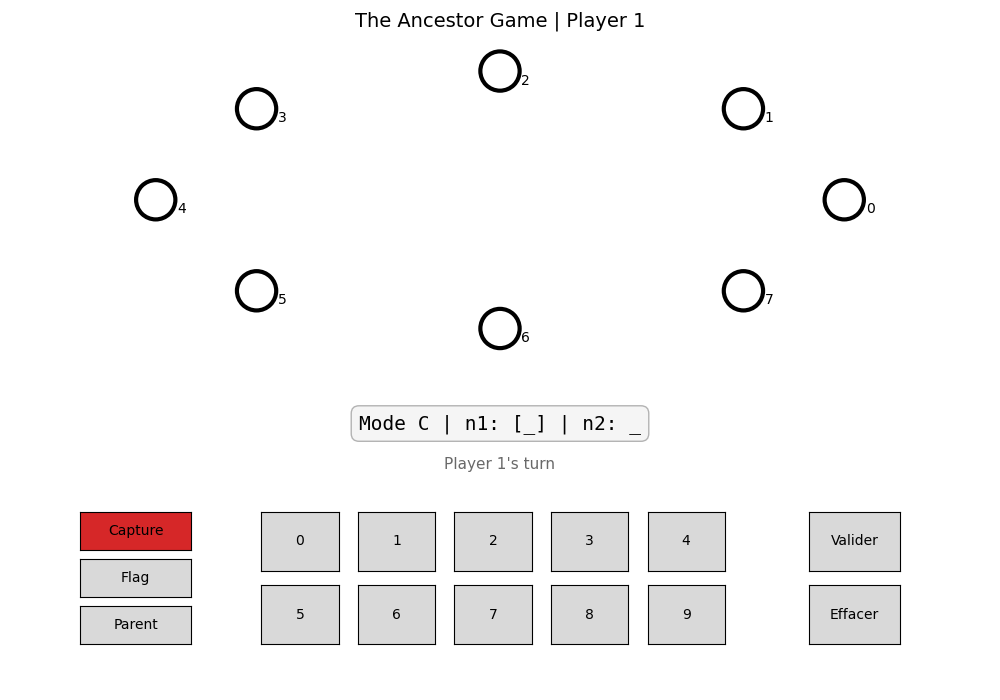

In [92]:
if "ui" in globals() and getattr(ui, "fig", None) is not None:
    try:
        plt.close(ui.fig)
    except Exception:
        pass

game = Game(Player(0), Player(1), 8)
minmax_node = AncestorState(8)

controller = NotebookGameController(game)
callbacks = GamePeritelCallbacks(controller)
ui = create_layout(callbacks)